# 🏁 Model 11 — Final Champion Duel

Optimized Hybrid Model.


--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.66      0.64      0.65      4133

    accuracy                           0.98    118108
   macro avg       0.83      0.81      0.82    118108
weighted avg       0.98      0.98      0.98    118108

ROC-AUC: 0.9466
PR-AUC: 0.6920


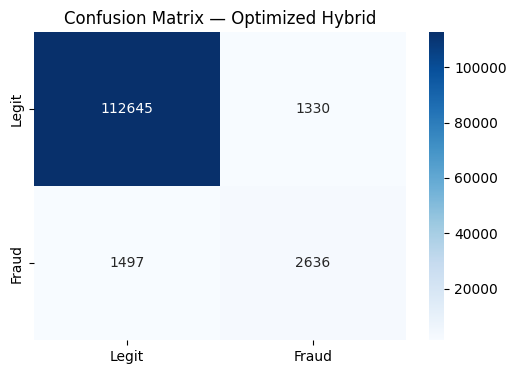

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# Load
train = pd.read_csv('../data/train_balanced.csv')
test = pd.read_csv('../data/test.csv')

X_train_raw = train.drop(columns=['isFraud'])
y_train = train['isFraud']
X_test_raw = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_test = test['isFraud']

# Targeted PCA on V-features
v_cols = [c for c in X_train_raw.columns if c.startswith('V')]
scaler_v = StandardScaler()
Xv_train_scaled = scaler_v.fit_transform(X_train_raw[v_cols])
Xv_test_scaled  = scaler_v.transform(X_test_raw[v_cols])

pca = PCA(n_components=0.95, random_state=42)
Xv_pca_train = pca.fit_transform(Xv_train_scaled)
Xv_pca_test  = pca.transform(Xv_test_scaled)

# Construct Hybrid Features
pca_names = [f'V_PCA_{i}' for i in range(Xv_pca_train.shape[1])]
X_train = pd.concat([X_train_raw.reset_index(drop=True), pd.DataFrame(Xv_pca_train, columns=pca_names)], axis=1)
X_test = pd.concat([X_test_raw.reset_index(drop=True), pd.DataFrame(Xv_pca_test, columns=pca_names)], axis=1)

# Train Duel Winner
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(n_estimators=400, max_depth=9, learning_rate=0.03, scale_pos_weight=imbalance_ratio, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, preds))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
precision, recall, _ = precision_recall_curve(y_test, probs)
print(f"PR-AUC: {auc(recall, precision):.4f}")

# Plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Optimized Hybrid')
plt.show()